<a href="https://colab.research.google.com/github/julianvanegas/DB-Structure/blob/main/KD_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de logística con Árbol KD (K-Dimensiones)

Por Julian Vanegas López (julian.vanegasl@udea.edu.co)

**Problema:** Tenemos $10,000$ puntos de entrega en una ciudad y necesitamos saber ¿cuál es el punto de entrega más cercano a una ubicación dada? y ¿qué puntos de entrega están a un radio determinado de un punto dado?

**Estrategia:** Implementar un Árbol KD y compararlo contra fuerza bruta utilizando listas.

## Librerías

In [ ]:
from typing import Optional, List, Tuple, Any
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import numpy as np
import random
import time

## Generación de datos

Generamos $10.000$ puntos de entrega con coordenadas cartesianas (en metros) dentro del intervalo $[-15000, 15000]$ en ambos ejes.

In [ ]:
N_POINTS = 10000 # Cantidad de puntos de entrega

zones = [
    {"centro": (0, 0),         "std": (3000, 2500), "peso": 0.25},  # Centro
    {"centro": (3000, 8000),   "std": (2500, 2000), "peso": 0.15},  # Norte
    {"centro": (-2000, -8000), "std": (3500, 2500), "peso": 0.20},  # Sur
    {"centro": (5000, -4000),  "std": (2000, 3500), "peso": 0.18},  # Oriente
    {"centro": (-5000, 4000),  "std": (2000, 2500), "peso": 0.22},  # Occidente
    ]

delivery_points = []
for zone in zones:
    z = int(N_POINTS * zone["peso"])
    cx, cy = zone["centro"]
    sx, sy = zone["std"]
    xs = np.random.normal(cx, sx, z)
    ys = np.random.normal(cy, sy, z)
    delivery_points.append(np.column_stack([xs, ys]))

# Ajustamos para tener exactamente N_POINTS
delivery_points = np.vstack(delivery_points)[:N_POINTS]

print(f"{len(delivery_points):,} puntos de entrega generados")
print(f"X: [{delivery_points[:,0].min():.0f}m, {delivery_points[:,0].max():.0f}m]")
print(f"Y: [{delivery_points[:,1].min():.0f}m, {delivery_points[:,1].max():.0f}m]")
print(f"Tipo: {delivery_points.dtype}")

10,000 puntos de entrega generados
X: [-13622m, 11091m]
Y: [-17041m, 14829m]
Tipo: float64


### Visualización de todos los puntos de entrega

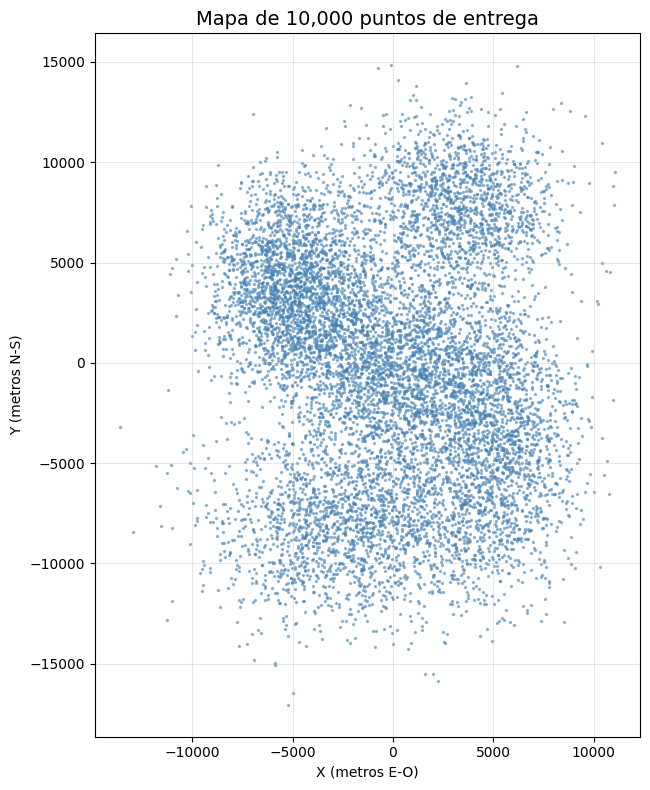

In [ ]:
# Visualización de los puntos de entrega
fig, ax = plt.subplots(figsize=(8, 8))

# Todos los puntos de entrega
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=2, alpha=0.5, color='steelblue', label='Puntos de entrega')

ax.set_title(f'Mapa de {N_POINTS:,} puntos de entrega', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Implementación del Árbol KD (K-Dimensiones)

El Árbol KD organiza los puntos de forma jerárquica mediante la partición sucesiva del espacio. Esto permite descartar grandes regiones de puntos que no pueden contener la solución, logrando una complejidad promedio de $O(\log n)$ por búsqueda.

In [ ]:
class KDNode:
  """
  Nodo del Árbol KD.

  Atributos:
      punto: coordenadas del punto en este nodo (array de K dimensiones)
      indice: índice original del punto en el dataset
      eje: dimensión por la que se divide (0=X, 1=Y, 2=Z, ...)
      izq: subárbol izquierdo (puntos con coord < mediana en el eje)
      der: subárbol derecho (puntos con coord >= mediana en el eje)
  """
  point: np.ndarray
  index: int
  axis: int
  left: Optional['KDNode'] = None
  right: Optional['KDNode'] = None

  def __init__(self, point: np.ndarray, index: int, axis: int):
    self.point = point
    self.index = index
    self.axis = axis
    self.left = None
    self.right = None


In [ ]:
class KDTree:
  """Árbol KD para K dimensiones."""

  def __init__(self, k: int = 2):
    """
    Args:
      k: número de dimensiones (por defecto 2 para espacio 2D)
    """
    self.k = k
    self.root: Optional['KDNode'] = None
    self.n_points = 0


  def build(self, points: np.ndarray):
    """Construye el árbol KD a partir de un array de puntos.
    Args:
      points: array de shape (n, k)
    """
    assert points.shape[1] == self.k, \
      f"Los puntos deben tener {self.k} dimensiones, se recibieron {points.shape[1]}"

    self.n_points = len(points)
    # Crear array de índices para mantener referencia al punto original
    indexes = np.arange(len(points))
    self.root = self._build(points, indexes, 0)


  def _build(self, points: np.ndarray, indexes: np.ndarray, depth: int) -> Optional['KDNode']:
    """Construcción recursiva del árbol."""
    if len(points) == 0:
      return None

    # Paso 1: Elegir el eje de división
    axis = depth % self.k
    # Paso 2: Ordenar los puntos por ese eje
    sort = np.argsort(points[:, axis])
    sort_points = points[sort]
    sort_indexes = indexes[sort]
    # Paso 3: El punto del medio es la raíz del subárbol
    mid = len(points) // 2
    # Paso 4: Crear el nodo con el punto mediano
    node = KDNode(sort_points[mid], sort_indexes[mid], axis)
    # Paso 5: Construir subárboles recursivamente
    node.left = self._build(sort_points[:mid], sort_indexes[:mid], depth + 1)
    node.right = self._build(sort_points[mid+1:], sort_indexes[mid+1:], depth + 1)

    return node


  def neighbor(self, coordinates: np.ndarray) -> Tuple[int, float, np.ndarray]:
    """Encuentra el vecino más cercano al punto de consulta.
    Args:
      consulta: punto de consulta, array de shape (k,)
    Returns:
      Tuple(índice del vecino, distancia, coordenadas del vecino)
    """
    assert len(coordinates) == self.k, \
      f"Los puntos deben tener {self.k} dimensiones, se recibieron {len(coordinates)}"

    self._distance = math.inf
    self._index = -1
    self._point = None
    self._neighbor(self.root, coordinates)

    return self._index, self._distance, self._point


  def _neighbor(self, node: Optional['KDNode'], coordinates: np.ndarray) -> None:
    """Búsqueda recursiva del vecino más cercano."""
    if node is None:
      return

    # Calcular la distancia euclidiana al nodo actual
    distance = self._euclidean(coordinates, node.point)

    # Actualizar mejor candidato si encontramos uno más cercano
    if distance < self._distance:
      self._distance = distance
      self._index = node.index
      self._point = node.point

    # Determinar qué subárbol explorar primero (el que contiene el punto de consulta es más probable)
    axis = node.axis
    diff = coordinates[axis] - node.point[axis]
    if diff <= 0:
      first = node.left
      second = node.right
    else:
      first = node.right
      second = node.left
    # Explorar el subárbol más probable primero
    self._neighbor(first, coordinates)

    # Poda: Si la distancia al hiperplano de corte (|coordinates[axis]-node.point[axis]|) es menor que la mejor distancia actual el otro subárbol podría contener un punto más cercano.
    if abs(diff) < self._distance:
      self._neighbor(second, coordinates)


  def _euclidean(self, a: np.ndarray, b: np.ndarray) -> float:
    """Distancia euclidiana entre dos puntos en K dimensiones."""
    return math.sqrt(sum((ai-bi)**2 for ai, bi in zip(a, b)))


  def nearby(self, coordinates: np.ndarray, radio: float) -> List[Tuple[int, float, np.ndarray]]:
    """Encuentra todos los puntos dentro de un radio.
    Args:
      consulta: punto de consulta, array de shape (k,)
      radio: radio de búsqueda en las mismas unidades que los puntos
    Returns:
      Lista de (índice, distancia, coordenadas) ordenada por distancia
    """
    assert len(coordinates) == self.k, \
      f"Los puntos deben tener {self.k} dimensiones, se recibieron {len(coordinates)}"

    results = []
    self._nearby(self.root, coordinates, radio, results)
    results.sort(key = lambda x: x[1]) # Ordenar ascendentemente por distancia

    return results

  def _nearby(self, node: Optional['KDNode'], coordinates: np.ndarray, radio: float, results: list) -> None:
    """Búsqueda recursiva por radio."""
    if node is None:
      return

    # Verificar si el nodo actual está dentro del radio
    distance = self._euclidean(coordinates, node.point)
    if distance <= radio:
      results.append((node.index, distance, node.point))

    # Determinar lado del hiperplano donde está la consulta
    axis = node.axis
    diff = coordinates[axis] - node.point[axis]

    # Explorar el subárbol del mismo lado siempre
    if diff <= 0:
      self._nearby(node.left, coordinates, radio, results)
      # Poda: explorar el otro lado SOLO si el hiperplano está dentro del radio
      if abs(diff) <= radio:
        self._nearby(node.right, coordinates, radio, results)
    else:
      self._nearby(node.right, coordinates, radio, results)
      if abs(diff) <= radio:
        self._nearby(node.left, coordinates, radio, results)


  def depth(self) -> int:
    """Calcula la profundidad máxima del árbol."""
    return self._depth(self.root)


  def _depth(self, node: Optional['KDNode']) -> int:
    if node is None:
      return 0
    return 1 + max(self._depth(node.left), self._depth(node.right))


  def count_nodes(self) -> int:
    """Cuenta el total de nodos en el árbol."""
    return self._count_nodes(self.root)


  def _count_nodes(self, node: Optional['KDNode']) -> int:
    if node is None:
      return 0
    return 1 + self._count_nodes(node.left) + self._count_nodes(node.right)


### Construcción del árbol KD

In [ ]:
# Construir el árbol KD con los 10.000 puntos
tree = KDTree()

t0 = time.perf_counter()
tree.build(delivery_points)
t_f = time.perf_counter() - t0

print(f"Tiempo de construcción  {t_f*1000:.2f}ms")
print(f"Puntos almacenados      {tree.n_points:,}")
print(f"Nodos totales           {tree.count_nodes():,}")
print(f"Profundidad             {tree.depth()}")
print(f"Profundidad ideal       log2({N_POINTS:,}) ≈ {math.log2(N_POINTS):.1f}")

Tiempo de construcción  190.59ms
Puntos almacenados      10,000
Nodos totales           10,000
Profundidad             14
Profundidad ideal       log2(10,000) ≈ 13.3


## Operaciones de consulta

### Tu ubicación

A continuación define tu ubicación en el mapa (plano) desde el cual deseas realizar las búsquedas.

In [ ]:
default = [500.0, 1200.0]

x = input(f"Ingresa la coordenada X de tu ubicación (por defecto {default[0]:.0f}m): ")
y = input(f"Ingresa la coordenada Y de tu ubicación (por defecto {default[1]:.0f}m): ")
location = np.array([float(x) if x else default[0], float(y) if y else default[1]])

print(f"\nTu ubicación es: ({location[0]}m, {location[1]}m)")

#### Visualización de tu ubicación en el espacio

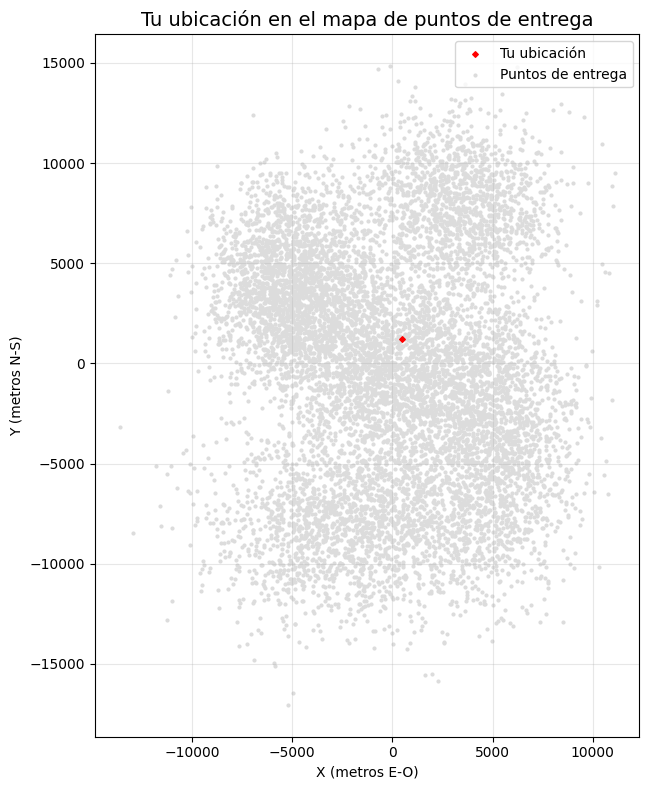

In [ ]:
# Visualización del punto de consulta (tu ubicación)
fig, ax = plt.subplots(figsize=(8, 8))
cx, cy = location

# Punto de consulta
ax.scatter([cx], [cy], s=8, color='red', label='Tu ubicación', zorder=6, marker='D')

# Todos los puntos de entrega
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=4, color='gainsboro', label='Puntos de entrega')

ax.set_title(f'Tu ubicación en el mapa de puntos de entrega', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Búsqueda del punto de entrega más cercano

In [ ]:
t0 = time.perf_counter()
index, distance, neighbor = tree.neighbor(location)
t_n = time.perf_counter() - t0

print(f"CONSULTA")
print(f"  Coordenadas ({location[0]:.0f}m, {location[1]:.0f}m)")

print(f"\nRESULTADO")
print(f"  Índice del punto     {index}")
print(f"  Coordenadas          ({neighbor[0]:.1f}m, {neighbor[1]:.1f}m)")
print(f"  Distancia            {distance:.2f}m")
print(f"  Tiempo de búsqueda   {t_n*1000:.4f}ms")

CONSULTA
  Coordenadas (500m, 1200m)

RESULTADO
  Índice del punto     750
  Coordenadas          (562.2m, 1266.8m)
  Distancia            91.28m
  Tiempo de búsqueda   0.2545ms


#### Visualización del punto de entrega más cercano

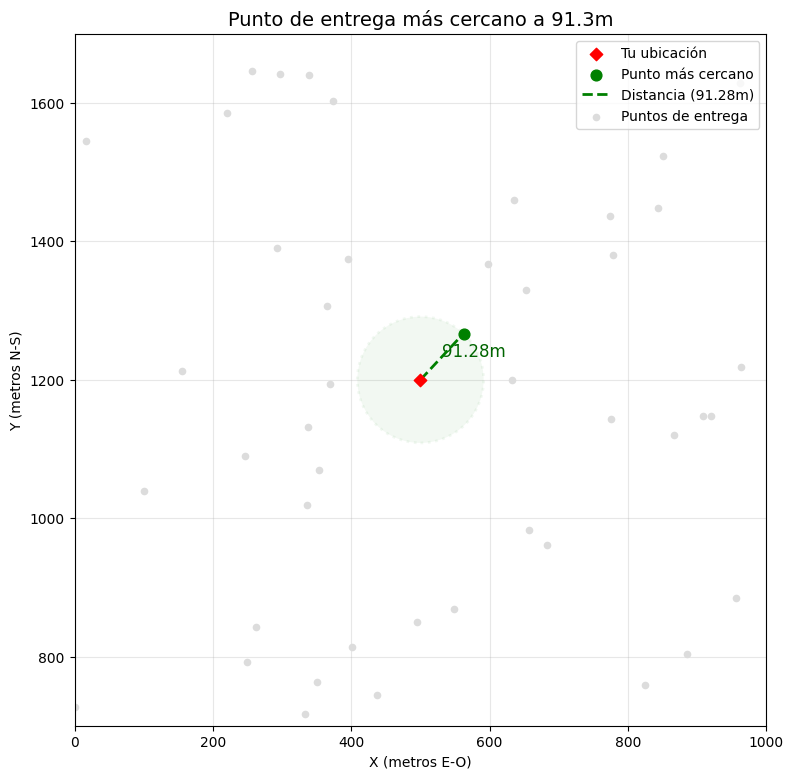

In [ ]:
# Visualización del punto más cercano
fig, ax = plt.subplots(figsize=(8, 8))

# Rango de visualización (zoom al área de interés)
margen = 500
cx, cy = location
ax.set_xlim(cx - margen, cx + margen)
ax.set_ylim(cy - margen, cy + margen)

# Punto de consulta
ax.scatter([cx], [cy], s=40, color='red', label='Tu ubicación', zorder=6, marker='D')

# Punto más cercano
ax.scatter([neighbor[0]], [neighbor[1]], s=60, color='green', label=f'Punto más cercano', zorder=5)

# Distancia al punto más cecano
ax.plot([cx, neighbor[0]], [cy, neighbor[1]], color='green', linewidth=2, linestyle='--', zorder=4, label=f'Distancia ({distance:.2f}m)')

# Radio al punto más cercano
ax.add_patch(plt.Circle((cx, cy), distance, fill=True, facecolor='green', alpha=0.05, edgecolor='green', linewidth=2, linestyle=':', zorder=3))

# Anotación de distancia
mid_x = (cx + neighbor[0]) / 2
mid_y = (cy + neighbor[1]) / 2
ax.annotate(f'{distance:.2f}m', xy=(mid_x, mid_y), fontsize=12, color='darkgreen', xytext=(mid_x, mid_y))

# Todos los puntos
ax.scatter(delivery_points[:, 0], delivery_points[:, 1], s=20, color='gainsboro', label='Puntos de entrega', zorder=2)

ax.set_title(f'Punto de entrega más cercano a {distance:.1f}m', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Búsqueda de los puntos de entrega cercanos dentro de un radio

A continuación define el radio en el cual deseas realizar la búsqueda.

In [ ]:
default = 500

print(f"Tu ubicación es: ({location[0]:.0f}m, {location[1]:.0f}m)")

radio = input(f"\nIngresa el radio para buscar (por defecto {default}m): ")
radio = radio if radio else default

Tu ubicación es: (500m, 1200m)

Ingresa el radio para buscar (por defecto 500m): 


Realiza la búsqueda de los puntos de entrega más cercanos dentro del radio definido.

In [ ]:
t0 = time.perf_counter()
nearby = tree.nearby(location, radio)
t_r = time.perf_counter() - t0

print(f"CONSULTA")
print(f"  Coordenadas ({location[0]:.0f}m, {location[1]:.0f}m)")
print(f"  Radio       {radio}m")

print(f"\nRESULTADO")
print(f"  Puntos encontrados  {len(nearby)}")
print(f"  Tiempo de búsqueda  {t_r*1000:.4f} ms")
if nearby:
    print(f"\n  Los 3 puntos de entrega más cercanos:")
    print(f"  {'Índice':<8}  {'X (m)':<10}  {'Y (m)':<10}  {'Distance (m)':<10}")
    print(f"  {'-'*46}")
    for i, (idx, dist, p) in enumerate(nearby[:3]):
        print(f"  {idx:<8}  {p[0]:<10.2f}  {p[1]:<10.2f}  {dist:<10.2f}")

CONSULTA
  Coordenadas (500m, 1200m)
  Radio       500m

RESULTADO
  Puntos encontrados  37
  Tiempo de búsqueda  0.6337 ms

  Los 3 puntos de entrega más cercanos:
  Índice    X (m)       Y (m)       Distance (m)
  ----------------------------------------------
  750       562.19      1266.81     91.28     
  1728      368.64      1193.84     131.50    
  1116      632.65      1200.33     132.65    


#### Visualización de los puntos de entrega cercanos

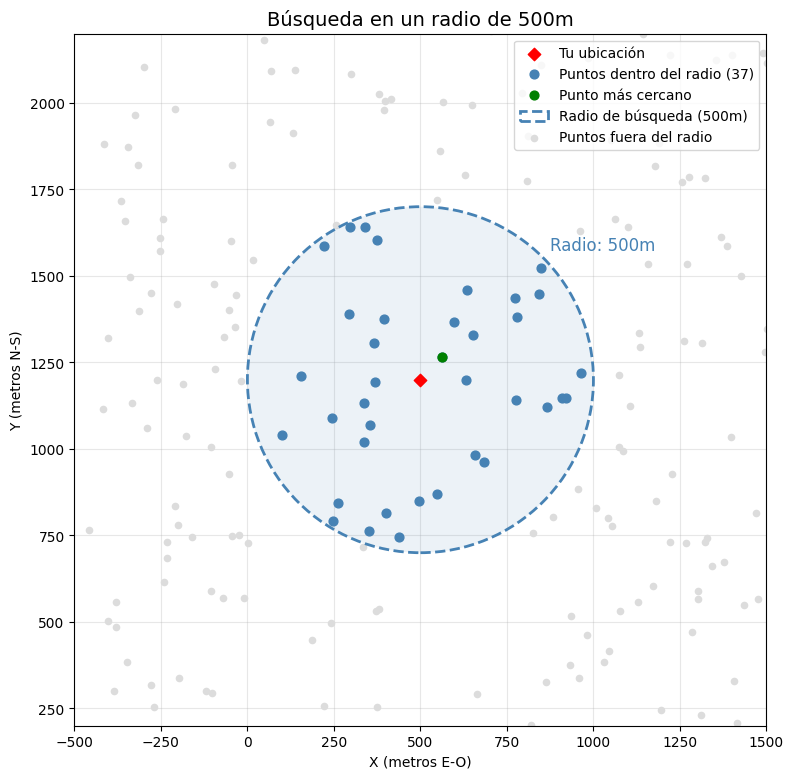

In [ ]:
# Visualización de los puntos dentro de un radio
fig, ax = plt.subplots(figsize=(8, 8))

nearby_coords = np.array([v[2] for v in nearby]) if nearby else np.empty((0, 2))

# Rango de visualización (zoom al área de interés)
margen = 1000
cx, cy = location
ax.set_xlim(cx - margen, cx + margen)
ax.set_ylim(cy - margen, cy + margen)

# Punto de consulta
ax.scatter([cx], [cy], s=40, color='red', label='Tu ubicación', zorder=6, marker='D')

# Puntos dentro del radio
if len(nearby_coords) > 0:
  ax.scatter(nearby_coords[:, 0], nearby_coords[:, 1], s=40, color='steelblue', label=f'Puntos dentro del radio ({len(nearby)})', zorder=4)

# Punto más cercano
ax.scatter([neighbor[0]], [neighbor[1]], s=40, color='green', label=f'Punto más cercano', zorder=5)

# Radio de búsqueda
ax.add_patch(plt.Circle((cx, cy), radio, fill=True, facecolor='steelblue', alpha=0.1, zorder=3))
ax.add_patch(plt.Circle((cx, cy), radio, fill=False, edgecolor='steelblue', linewidth=2, linestyle='--', label=f'Radio de búsqueda ({radio}m)', zorder=3))

# Anotación del radio
ax.annotate(f'Radio: {radio}m', xy=(cx + radio*0.75, cy + radio*0.75), fontsize=12, color='steelblue', xytext=(cx + radio*0.75, cy + radio*0.75))

# Puntos fuera del radio
inside = np.zeros(len(delivery_points), dtype=bool)
if len(nearby) > 0:
  idx_inside = [v[0] for v in nearby]
  inside[idx_inside] = True
ax.scatter(delivery_points[~inside, 0], delivery_points[~inside, 1], s=20, color='gainsboro', label='Puntos fuera del radio', zorder=2)

ax.set_title(f'Búsqueda en un radio de {radio}m', fontsize=14)
ax.set_xlabel('X (metros E-O)')
ax.set_ylabel('Y (metros N-S)')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Implementación con listas



La implementación de listas o fuerza bruta revisa todos los puntos para cada consulta, es una búsqueda lineal, por lo que tiene complejidad $O(n)$ en cada búsqueda.

In [ ]:
class Force:

  def __init__(self):
    self.points = None


  def build(self, points: np.ndarray) -> None:
    self.points = points


  def neighbor(self, coordinates: np.ndarray) -> Tuple[int, float, np.ndarray]:
    distance = math.inf
    index = -1
    for i, point in enumerate(self.points):
      dist = math.sqrt(sum((a - b)**2 for a, b in zip(coordinates, point)))
      if dist < distance:
        distance = dist
        index = i

    return index, distance, self.points[index]


  def nearby(self, coordinates: np.ndarray, radio: float) -> List[Tuple[int, float, np.ndarray]]:
    results = []
    for i, point in enumerate(self.points):
      distance = math.sqrt(sum((a - b)**2 for a, b in zip(coordinates, point)))
      if distance <= radio:
        results.append((i, distance, point))
      results.sort(key=lambda x: x[1])

    return results


### Construcción de las estructuras de lista

In [ ]:
# Estructuras de lista
force = Force()

t0 = time.perf_counter()
force.build(delivery_points)
t_f = time.perf_counter() - t0

print(f"Tiempo de construcción  {t_f*1000:.2f}ms")
print(f"* Solo alamcena una estructura de lista (array)")

Tiempo de construcción  0.62ms
* Solo alamcena una estructura de lista (array)


## Verificación de resultados

La verificación comprueba que los resultados obtenidos en cada consulta (del punto más cercano y los puntos dentro de un radio) coincidan en ambas implementaciones, como Árbol KD y listas o fuerza bruta.

In [ ]:
fb_index, fb_distance, fb_point = force.neighbor(location)
fb_nearby = force.nearby(location, radio)

print(f"\nVERIFICACIÓN DE RESULTADOS")
print(f"  Búsqueda del punto más cercano (vecino)")
print(f"    {'Método':<16}  {'Índice':<8} {'Distance (m)':>10}")
print(f"    {'-'*40}")
print(f"    {'KD Tree':<16}  {index:<8}  {distance:>10.2f}m")
print(f"    {'Fuerza Bruta':<16}  {fb_index:<8}  {fb_distance:>10.2f}m")
print(f"  RESULTADO: {'Coinciden' if index == fb_index else 'No coinciden'}")

print(f"\n  Búsqueda de puntos dentro del radio")
print(f"    KD Tree       {len(nearby)} puntos")
print(f"    Fuerza Bruta  {len(fb_nearby)} puntos")
print(f"  RESULTADO: {'Coinciden' if len(nearby) == len(fb_nearby) else 'No coinciden'}")


VERIFICACIÓN DE RESULTADOS
  Búsqueda del punto más cercano (vecino)
    Método            Índice   Distance (m)
    ----------------------------------------
    KD Tree           750            91.28m
    Fuerza Bruta      750            91.28m
  RESULTADO: Coinciden

  Búsqueda de puntos dentro del radio
    KD Tree       37 puntos
    Fuerza Bruta  37 puntos
  RESULTADO: Coinciden


## Análisis de rendimiento

La comparación de rendimiento se realiza entre el Árbol KD y la fuerza bruta con listas para diferentes tamaños de datos.

### Benchmark

In [ ]:
QUERIES = 50 # Consultas aleatorias por tamaño
REPETITIONS = 3 # Repeticiones
sizes = [100, 500, 1000, 2000, 5000, 10000] # Tamaños
benchmark = {'size': [], 't_kd_f': [], 't_kd_n': [], 't_kd_r': [], 't_fb_n': [], 't_fb_r': [], 'speed_n': [], 'speed_r': []}

print(f"{'Tamaño':>8} | {'KD Vecino (ms)':>14} | {'List Vecino (ms)':>16} | {'SpeedUp Vecino':>15} | {'KD Radio (ms)':>14} | {'List Radio (ms)':>16} | {'SpeedUp Radio':>15}")
print("-" * 118)

for n in sizes:
  # Tomar subconjunto de puntos
  bench_points = delivery_points[:n].copy()

  # Consultas aleatorias dentro del rango de datos
  queries = np.random.uniform(-10000, 10000, (QUERIES, 2))

  # KD Tree
  bench_tree = KDTree()
  t0 = time.perf_counter()
  for _ in range(REPETITIONS):
    bench_tree.build(bench_points)
  t_kd_f = (time.perf_counter() - t0) / REPETITIONS * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_tree.neighbor(q)
  t_kd_n = (time.perf_counter() - t0) / QUERIES * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_tree.nearby(q, radio)
  t_kd_r = (time.perf_counter() - t0) / QUERIES * 1000

  # Listas o fuerza bruta
  bench_force = Force()
  bench_force.build(bench_points)

  t0 = time.perf_counter()
  for q in queries:
    bench_force.neighbor(q)
  t_fb_n = (time.perf_counter() - t0) / QUERIES * 1000

  t0 = time.perf_counter()
  for q in queries:
    bench_force.nearby(q, radio)
  t_fb_r = (time.perf_counter() - t0) / REPETITIONS * 1000

  # SpeedUp
  speedup_n = t_fb_n / t_kd_n if t_kd_n > 0 else 0
  speedup_r = t_fb_r / t_kd_r if t_kd_r > 0 else 0

  benchmark['size'].append(n)
  benchmark['t_kd_f'].append(t_kd_f)
  benchmark['t_kd_n'].append(t_kd_n)
  benchmark['t_kd_r'].append(t_kd_r)
  benchmark['t_fb_n'].append(t_fb_n)
  benchmark['t_fb_r'].append(t_fb_r)
  benchmark['speed_n'].append(speedup_n)
  benchmark['speed_r'].append(speedup_r)

  print(f"{n:>8,} | {t_kd_n:>12.4f}ms | {t_fb_n:>14.4f}ms | {speedup_n:>14.2f}x | {t_kd_r:>12.4f}ms | {t_fb_r:>14.4f}ms | {speedup_r:>14.2f}x")

  Tamaño | KD Vecino (ms) | List Vecino (ms) |  SpeedUp Vecino |  KD Radio (ms) |  List Radio (ms) |   SpeedUp Radio
----------------------------------------------------------------------------------------------------------------------
     100 |       0.0387ms |         0.2429ms |           6.27x |       0.0268ms |         4.3784ms |         163.57x
     500 |       0.0532ms |         1.2274ms |          23.07x |       0.0380ms |        23.8756ms |         627.56x
   1,000 |       0.0692ms |         3.0627ms |          44.28x |       0.0600ms |        51.2710ms |         854.53x
   2,000 |       0.0883ms |         5.0621ms |          57.32x |       0.0959ms |        96.1118ms |        1001.70x
   5,000 |       0.0759ms |        13.2779ms |         174.97x |       0.1669ms |       271.6776ms |        1628.03x
  10,000 |       0.0867ms |        26.2763ms |         303.21x |       0.2654ms |       571.1919ms |        2151.90x


### Visualización del benchmark

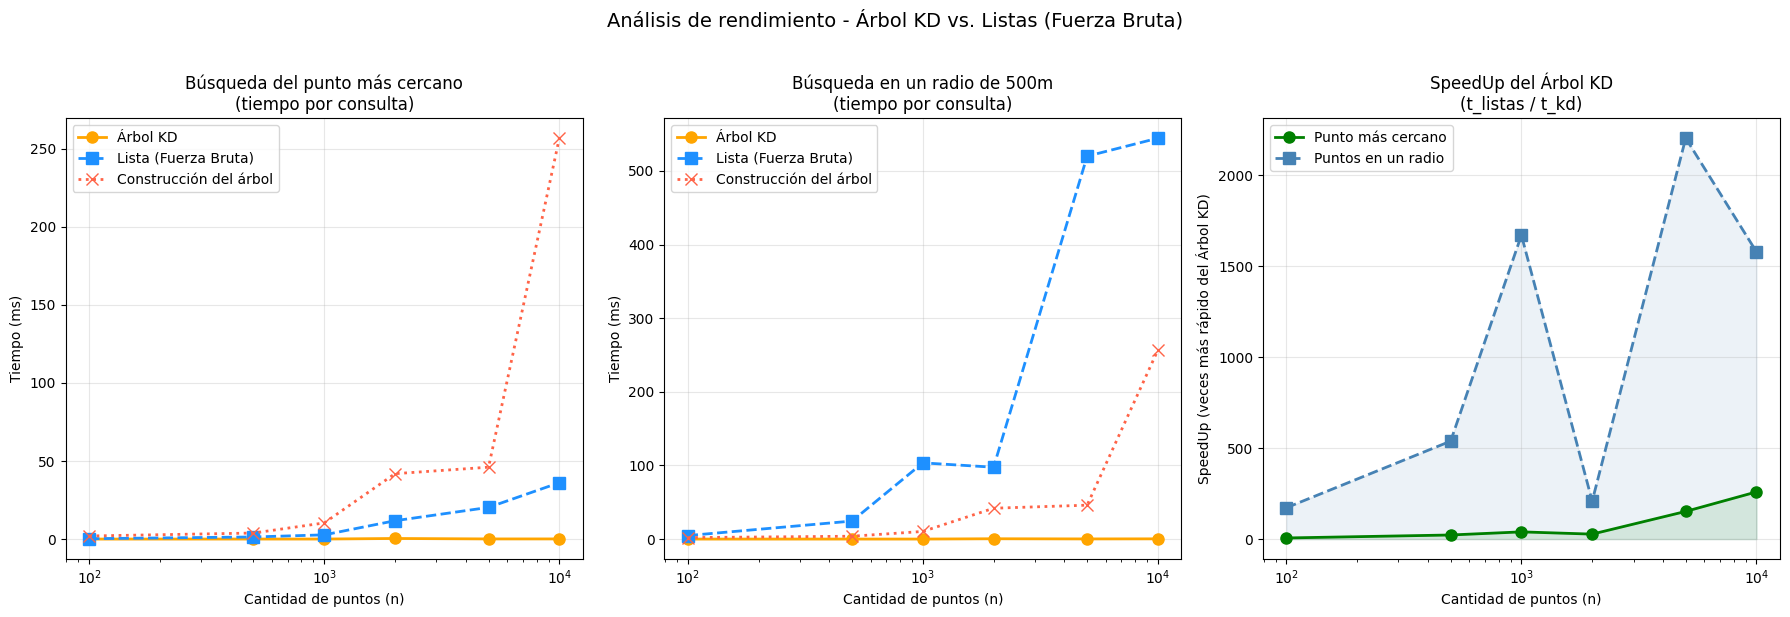

In [ ]:
# Visualización del benchmark
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Búsqueda del punto más cercano
ax = axes[0]
ax.plot(benchmark['size'], benchmark['t_kd_n'], 'o-', color='orange', label='Árbol KD', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_fb_n'], 's--', color='dodgerblue', label='Lista (Fuerza Bruta)', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_kd_f'], 'x:', color='tomato', label='Construcción del árbol', linewidth=2, markersize=8)
ax.set_title('Búsqueda del punto más cercano\n(tiempo por consulta)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('Tiempo (ms)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Búsqueda en un radio
ax = axes[1]
ax.plot(benchmark['size'], benchmark['t_kd_r'], 'o-', color='orange', label='Árbol KD', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_fb_r'], 's--', color='dodgerblue', label='Lista (Fuerza Bruta)', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['t_kd_f'], 'x:', color='tomato', label='Construcción del árbol', linewidth=2, markersize=8)
ax.set_title(f'Búsqueda en un radio de {radio}m\n(tiempo por consulta)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('Tiempo (ms)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Speedup
ax = axes[2]
ax.plot(benchmark['size'], benchmark['speed_n'], 'o-', color='green', label='Punto más cercano', linewidth=2, markersize=8)
ax.plot(benchmark['size'], benchmark['speed_r'],  's--', color='steelblue', label='Puntos en un radio', linewidth=2, markersize=8)
ax.fill_between(benchmark['size'], 1, benchmark['speed_r'], alpha=0.1, color='steelblue')
ax.fill_between(benchmark['size'], 1, benchmark['speed_n'], alpha=0.1, color='green')
ax.set_title('SpeedUp del Árbol KD\n(t_listas / t_kd)', fontsize=12)
ax.set_xlabel('Cantidad de puntos (n)')
ax.set_ylabel('SpeedUp (veces más rápido del Árbol KD)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.suptitle('Análisis de rendimiento - Árbol KD vs. Listas (Fuerza Bruta)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Conclusiones

El Árbol KD es superior desde el inicio para la búsqueda del punto más cercano, aproximadamente $7x$ más rápido en $n=100$, pero se justifica si se va a realizar múltiples consultas que compensen el costo inicial de construir el árbol.

Con $10,000$ puntos, el SpeedUp es de $∼260.4x$ para burcar el punto más cercano.  La ventaja crece con $n$ puesto que el KD Tree es $O(\log n)$ mientras que la fuerza bruta es lineal $O(n)$. Si bien en $n = 2,000$ se observa una caída en el SpeedUp esto podría deberse a la distribución específica de los puntos en la muestra.

La fuerza bruta en la búsqueda por radio es lenta porque debe calcular la distancia de todos los puntos para compararlos con el umbral; mientras el Árbol KD descarta conjuntos enteros de espacio, lo que genera una ventaja mayor.

Si bien el costo de construcción del Árbol KD es superado por la fuerza bruta, dado lo anterior, el uso del Árbol KD se justifica en escenarios de alta densidad de consultas o datasets dinámicos de gran escala.

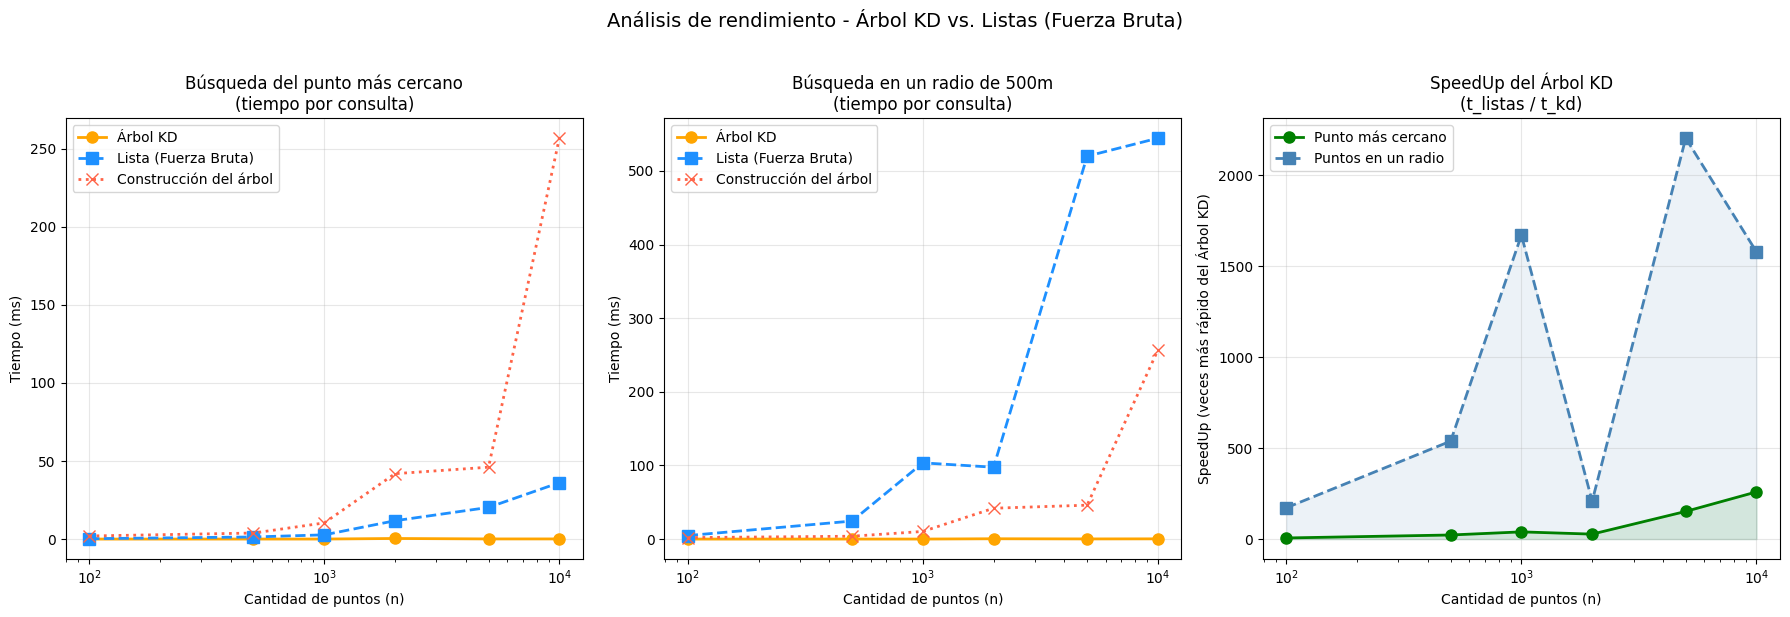